# **HEALTHCONNECT CLINIC : INITIAL DATA ANALYSIS**

## **1. Business Problem**

HealthConnect Clinic is experiencing operational and patient support challenges, including missed appointments, difficulty understanding the factors associated with no-shows, and inefficient use of appointment slots when patients fail to attend. The broader HealthConnect project aims to explore how data and AI can support better decision-making, reduce missed appointments and improve the patient experience.

This initial analysis focuses on understanding the appointment dataset, assessing its quality, identifying variables relevant to appointment attendance and no-show patterns, defining business questions and potential KPIs, and establishing an initial approach for further analysis.

## 2. Project Resources Reviewed

The following resources were reviewed to establish an understanding of the HealthConnect project and the available data :
- HealthConnect Experience Lab Assignment Brief
- HealthConnect Appointment Dataset
- HealthConnect Data Dictionary
- HealthConnect Clinic Knowledge Base

The data dictionary was used to understand the definitions, expected data types and intended meaning of the variables contained in the appointment dataset.

## 3. Importing Libraries and Loading the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("DOC-20260828-WA0001.csv")

In [3]:
df_raw=df.copy()

## 4. Dataset Overview

In [4]:
df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


In [5]:
df.tail()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
4995,HC-04996,P-0007,Male,49,45-54,Diagnostic Test,3/29/2025,4/26/2025,Saturday,Morning,28,5,1,Yes,Email,4.4,35.0,No-Show
4996,HC-04997,P-1501,Female,52,45-54,Follow-up,12/14/2025,2/12/2026,Thursday,Evening,60,6,2,Yes,WhatsApp,12.6,24.0,Attended
4997,HC-04998,P-0315,Male,59,55-64,General Consultation,3/3/2026,3/24/2026,Tuesday,Afternoon,21,5,0,No,NaN,22.8,28.0,Attended
4998,HC-04999,P-1262,Male,47,45-54,General Consultation,12/3/2025,1/6/2026,Tuesday,Morning,34,4,1,No,NaN,12.5,16.0,Attended
4999,HC-05000,P-1793,Female,19,18-24,General Consultation,8/24/2025,9/30/2025,Tuesday,Morning,37,6,1,Yes,WhatsApp,1.1,13.0,No-Show


In [7]:
df.sample(5)

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
3959,HC-03960,P-0361,Female,62,55-64,General Consultation,2/28/2025,4/28/2025,Monday,Morning,59,4,0,Yes,Email,22.6,16.0,No-Show
3020,HC-03021,P-0513,Male,65,65+,Diagnostic Test,6/23/2025,7/10/2025,Thursday,Morning,17,1,0,Yes,SMS,1.4,38.0,Attended
449,HC-00450,P-1565,Male,48,45-54,Diagnostic Test,5/27/2025,6/6/2025,Friday,Afternoon,10,5,2,No,NaN,12.9,13.0,No-Show
1582,HC-01583,P-0152,Male,25,25-34,General Consultation,9/2/2025,10/9/2025,Thursday,Morning,37,3,1,Yes,SMS,11.4,33.0,Attended
4239,HC-04240,P-0869,Male,59,55-64,Specialist Consultation,4/11/2025,5/12/2025,Monday,Afternoon,31,1,0,No,NaN,6.3,49.0,No-Show


In [8]:
df.shape

(5000, 18)

The HealthConnect appointment dataset contains 5,000 records and 18 variables. Each row represents an individual appointment record. The dataset contains information relative to patient demographics, appointment chaacteristics, booking information, previous appointment history, reminders, distance to the clinic, waiting time and appointment outcomes.

In [9]:
df.describe()

,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,waiting_time_minutes
count,5000.000000,5000.00000,5000.000000,5000.000000,4910.000000,4940.000000
mean,48.794800,29.63860,3.013800,0.544200,10.109572,24.189676
std,18.138547,17.39936,1.741211,0.746832,6.590030,10.863184
min,18.000000,0.00000,0.000000,0.000000,0.500000,2.000000
25%,33.000000,15.00000,2.000000,0.000000,5.300000,17.000000
50%,49.000000,30.00000,3.000000,0.000000,8.700000,24.000000
75%,64.000000,45.00000,4.000000,1.000000,13.500000,32.000000
max,80.000000,60.00000,11.000000,5.000000,45.000000,68.000000


Descriptive statistics were generated for numerical variables to obtain an initial understanding of their distributions, central tendencies and ranges. These observations will support further investigation of variables potentially associated with appointment attendance and no-show behaviour.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

The dataset structure was examined using df.info() to identify the number of non-null observations and the data types assigned to each variable. 

## 5. Initial Data Quality Assessment

In [11]:
df["patient_id"].value_counts()

patient_id
P-1399    9
P-1742    9
P-1776    9
P-0887    8
P-0252    8
         ..
P-1038    1
P-0255    1
P-1043    1
P-1650    1
P-1262    1
Name: count, Length: 1696, dtype: int64

In [13]:
df["reminder_channel"].isnull().sum()

np.int64(1366)

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.isnull().sum()

appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
appointment_outcome         0
dtype: int64

In [22]:
df["booking_date"]=pd.to_datetime(df["booking_date"])
df["appointment_date"]=pd.to_datetime(df["appointment_date"])

In [23]:
df["appointment_id"].duplicated().sum()

np.int64(0)

In [24]:
df["reminder_channel"].isnull().sum()

np.int64(1366)

In [25]:
pd.crosstab(df["reminder_sent"], df["reminder_channel"], dropna=False)

reminder_channel,Email,SMS,WhatsApp,NaN
reminder_sent,,,,
No,0,0,0,1366
Yes,533,2000,1101,0


In [26]:
df.loc[df["reminder_sent"] == "No", "reminder_channel"] = "None"

In [27]:
pd.crosstab(df["reminder_sent"], df["reminder_channel"], dropna=False)

reminder_channel,Email,None,SMS,WhatsApp
reminder_sent,,,,
No,0,1366,0,0
Yes,533,0,2000,1101


In [28]:
df["waiting_time_minutes"].describe()

count    4940.000000
mean       24.189676
std        10.863184
min         2.000000
25%        17.000000
50%        24.000000
75%        32.000000
max        68.000000
Name: waiting_time_minutes, dtype: float64

In [31]:
pd.crosstab(df["waiting_time_minutes"].isna(), df["appointment_outcome"], normalize="index")

appointment_outcome,Attended,Cancelled,No-Show
waiting_time_minutes,,,
False,0.46417,0.052834,0.482996
True,0.35000,0.033333,0.616667


In [32]:
df[df["distance_to_clinic_km"].isna()].head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
38,HC-00039,P-0072,Male,78,65+,General Consultation,2025-04-02,2025-06-01,Sunday,Afternoon,60,6,1,Yes,SMS,NaN,42.0,Cancelled
176,HC-00177,P-1036,Male,65,65+,General Consultation,2026-01-15,2026-01-27,Tuesday,Morning,12,2,0,Yes,Email,NaN,28.0,No-Show
443,HC-00444,P-1114,Female,53,45-54,Follow-up,2025-08-06,2025-09-24,Wednesday,Afternoon,49,4,1,No,None,NaN,18.0,No-Show
503,HC-00504,P-0705,Female,21,18-24,General Consultation,2026-03-06,2026-04-19,Sunday,Afternoon,44,3,0,Yes,SMS,NaN,36.0,No-Show
581,HC-00582,P-1596,Male,38,35-44,Follow-up,2026-02-10,2026-04-01,Wednesday,Morning,50,1,0,Yes,SMS,NaN,11.0,No-Show


In [35]:
pd.crosstab(df["distance_to_clinic_km"].isna(), df["appointment_outcome"], normalize="index") 

appointment_outcome,Attended,Cancelled,No-Show
distance_to_clinic_km,,,
False,0.463340,0.052749,0.483910
True,0.433333,0.044444,0.522222


Three variables were identified as containing missing values. The reminder_channel variable initially contained 1366 missing values, representing 27.32% of the dataset. Because this proportion was considerably larger than the missingness observed in other variables, further investigation was conducted to understand whether these values represented a genuine data quality issue. 

The distance_to_clinic_km variable contained 90 missed values while waiting_time_minutes contained 60 missing values. Both represent limited missingness and will require further investigation before a decision is made regarding imputation or exclusion.

A cross-tabulation was conducted between reminder_sent and reminder_channel to investigate the missing values observed in the reminder_channel variable. The analysis showed that all 1366 missing values in reminder_channel corresponded to appointments where no reminder was sent.

This finding indicates that the missing values are structural rather than necessarily resulting from incomplete or poor-quality data.

In [36]:
df.nunique()

appointment_id           5000
patient_id               1696
gender                      3
age                        63
age_group                   6
appointment_type            4
booking_date              593
appointment_date          545
appointment_day             7
appointment_time            3
booking_lead_days          61
previous_appointments      12
previous_no_shows           6
reminder_sent               2
reminder_channel            4
distance_to_clinic_km     335
waiting_time_minutes       62
appointment_outcome         3
dtype: int64

No duplicate appointment records were identified.

In [39]:
df["gender"].value_counts()

gender
Female               2488
Male                 2404
Prefer not to say     108
Name: count, dtype: int64

## 6. Relevant Variable for Further Analysis

Based on the business problem the following were identified as particularly relevant for investigating :

#### Appointment Outcome
- appointment_outcome
#### Appointment Characteristics
- appointment_type
- appointment_day
- appointment_time
- booking_lead_days
- waiting_time_minutes
#### Previous Attendance History
- previous_appointment
- previous_no_shows
#### Patient Communication
- reminder_sent
- reminder_channel
#### Accessibility
- distance_to_clinic_km

These variables will form the basis of the subsequent exploratory analysis.

## 7. Initial Exploratory Analysis and Visualisations

A correlation analysis was conducted for numerical variables to explore the strength and direction of linear relationships between variables.

In [40]:
numerical_columns=[
    "age",
    "booking_lead_days",
    "previous_no_shows",
    "distance_to_clinic_km",
    "waiting_time_minutes"
]
corr_matrix=df[numerical_columns].corr()
corr_matrix

,age,booking_lead_days,previous_no_shows,distance_to_clinic_km,waiting_time_minutes
age,1.000000,-0.026700,0.012409,0.002476,0.005584
booking_lead_days,-0.026700,1.000000,0.000206,-0.007494,0.009729
previous_no_shows,0.012409,0.000206,1.000000,0.009621,-0.001965
distance_to_clinic_km,0.002476,-0.007494,0.009621,1.000000,-0.007561
waiting_time_minutes,0.005584,0.009729,-0.001965,-0.007561,1.000000


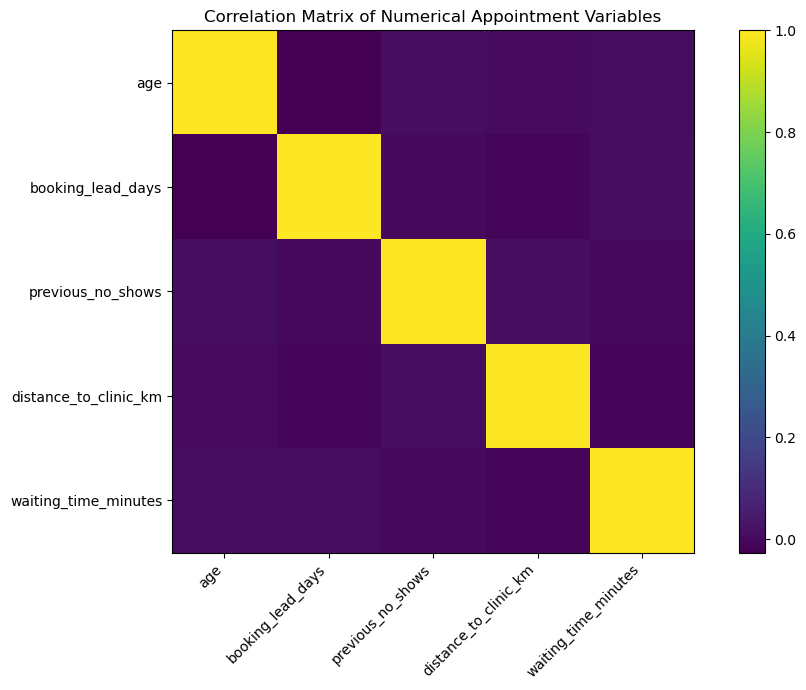

In [46]:
plt.figure(figsize=(10,7))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Correlation Matrix of Numerical Appointment Variables")
plt.tight_layout()
plt.show()

The correlation matrix provides an initial overview of relationships between numerical variables. These relationships will be investigated further in subsequent stages where relevant to appointment attendance and no-show patterns.

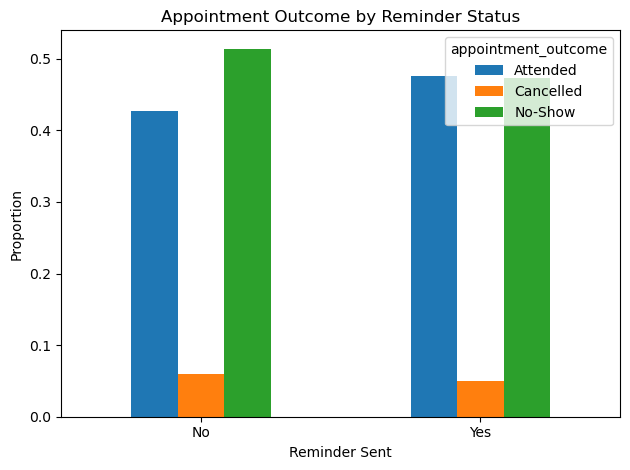

In [48]:
pd.crosstab(
    df["reminder_sent"], df["appointment_outcome"], normalize="index"
).plot(kind="bar")
plt.title("Appointment Outcome by Reminder Status")
plt.xlabel("Reminder Sent")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

This visualisation provides an initial comparison of appointment outcomes between appointments where reminders were sent and appointments where no reminder was sent. Further analysis will invetigate whether reminder practices are associated with differences in appointment attendance.

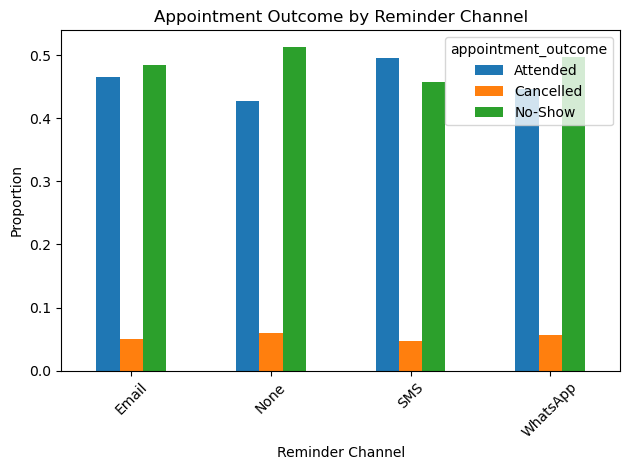

In [51]:
pd.crosstab(
    df["reminder_channel"], df["appointment_outcome"], normalize="index"
).plot(kind="bar")
plt.title("Appointment Outcome by Reminder Channel")
plt.xlabel("Reminder Channel")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The reminder channel analysis will compare appointment outcomes across the available reminder channels, while also recognising appointments for which no reminder was sent. 

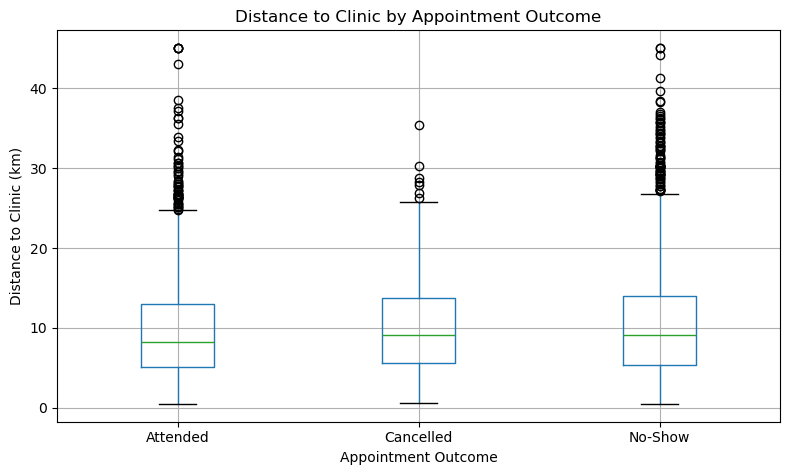

In [52]:
df.boxplot(
    column="distance_to_clinic_km",
    by="appointment_outcome",
    figsize=(8,5)
)
plt.title("Distance to Clinic by Appointment Outcome")
plt.suptitle("")
plt.xlabel("Appointment Outcome")
plt.ylabel("Distance to Clinic (km)")
plt.tight_layout()
plt.show()

This visualisation provides an initial comparison of the distribtion of distance to the clinic across appointment outcomes. It will support further investigation into whether accessibility, as represented by approximate distance, is associated with appointment attendance patterns.

## 8. Business Questions

1. How does appointment type relate to appointment outcomes ?
2. Does receiving an appointment reminder relate to appointment attendance ?
3. Which reminder channels are associated with the highest appointment attendance rates ?
4. How do previous no-shows relate to the outcome of a current appointment ?
5. How does distance from the clinic relate to appointment outcomes ? 

## 9. Potential KPIs
1. Appointment Attendance Rate : Measures successful appointment attendance
2. Appointment No-Show Rate : Measures missed appointments
3. Reminder Effectiveness Rate : Compares attendance where reminders were and were not sent
4. Attendance Rate by Reminder Channel : Helps compare communication channels
5. Attendance Rate by Previous No-Show History : Investigates repeat no-show behaviour

## 10. Initial Analysis Approach
1. Data preparation and validation : Data types, missing values, duplicate records and categorical values will be validated. Significant data transformation will be documented, and cleaned data will be maintained separately from the original dataset.
2. Descriptive analysis : The distribution of appointment outcomes and key variables will be explored to understand the overall characteristics of the data.
3. Relationship analysis : Relationships between appointment outcomes and variables relating to appointment characteristics, reminder practices, previos attendance behaviour and accessibility will be investigated.
4. Visualisation and Insight generation : Appropriate visualisations will be used to identify patterns and communicate findings clearly.

## 11. Assumptions, Limitations and Risks
Several considerations may affect the interpretation of the analysis :
- The dataset is fictional and anonymised for the Experience Lab.
- Some numerical variables contain missing values that require further investigation before treatment.
- The dataset may not capture every factor influencing appointment attendance.
- Observed asociations or correlations should not be interpreted as evidence of causation.

## 12. Proposed Focus for Week 5

Week 5 will focus on conducting a deeper exploratory analysis of appointment attendance and no-show patterns. The analysis will investigate relationships between appointment outcomes and appointment characteristics, reminder practices, previous attendance behaviour and accessibility factors.

The objective will be to identify meaningful patterns that can support evidence-based recommendations for improving appointment attendance and reducin missed appointments.